# End-to-End Customer Churn Prediction Pipeline

This notebook demonstrates a production-ready machine learning pipeline using Scikit-learn to predict customer churn using the Telco Customer Churn dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

start_time = time.time()
sns.set(style='whitegrid')

# Load Dataset
url = 'https://raw.githubusercontent.com/dataset-repo/telco-customer-churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv'
try:
    df = pd.read_csv(url)
except:
    # Fallback URL
    url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
    df = pd.read_csv(url)

print('Dataset Loaded successfully.')

Dataset Loaded successfully.


## Step 1 — Data Inspection & Validation

In [2]:
print('--- Head ---')
display(df.head())
print('\n--- Sample ---')
display(df.sample(5))
print(f'\nShape: {df.shape}')
print('\n--- Info ---')
df.info()
print('\n--- Describe ---')
display(df.describe(include='all'))
print('\n--- Null Values ---')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')

--- Head ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Sample ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2897,8234-GSZYK,Male,0,No,No,43,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),26.45,1110.05,No
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
3502,6738-ISCBM,Male,0,No,No,44,No,No phone service,DSL,Yes,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,54.00,2440.25,No
1188,0080-OROZO,Female,0,No,No,35,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,99.25,3532,No
6908,1750-CSKKM,Male,0,No,Yes,9,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,No,Electronic check,55.35,449.75,Yes



Shape: (7043, 21)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperless

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN



--- Null Values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicates: 0


**Observations:**
- The dataset contains 7043 rows and 21 columns.
- `TotalCharges` is currently an object type due to empty strings; this needs conversion.
- No explicit null values detected, but empty strings in `TotalCharges` act as hidden missing data.

## Step 2 — Exploratory Data Analysis

/tmp/ipykernel_26035/1018009558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='viridis')


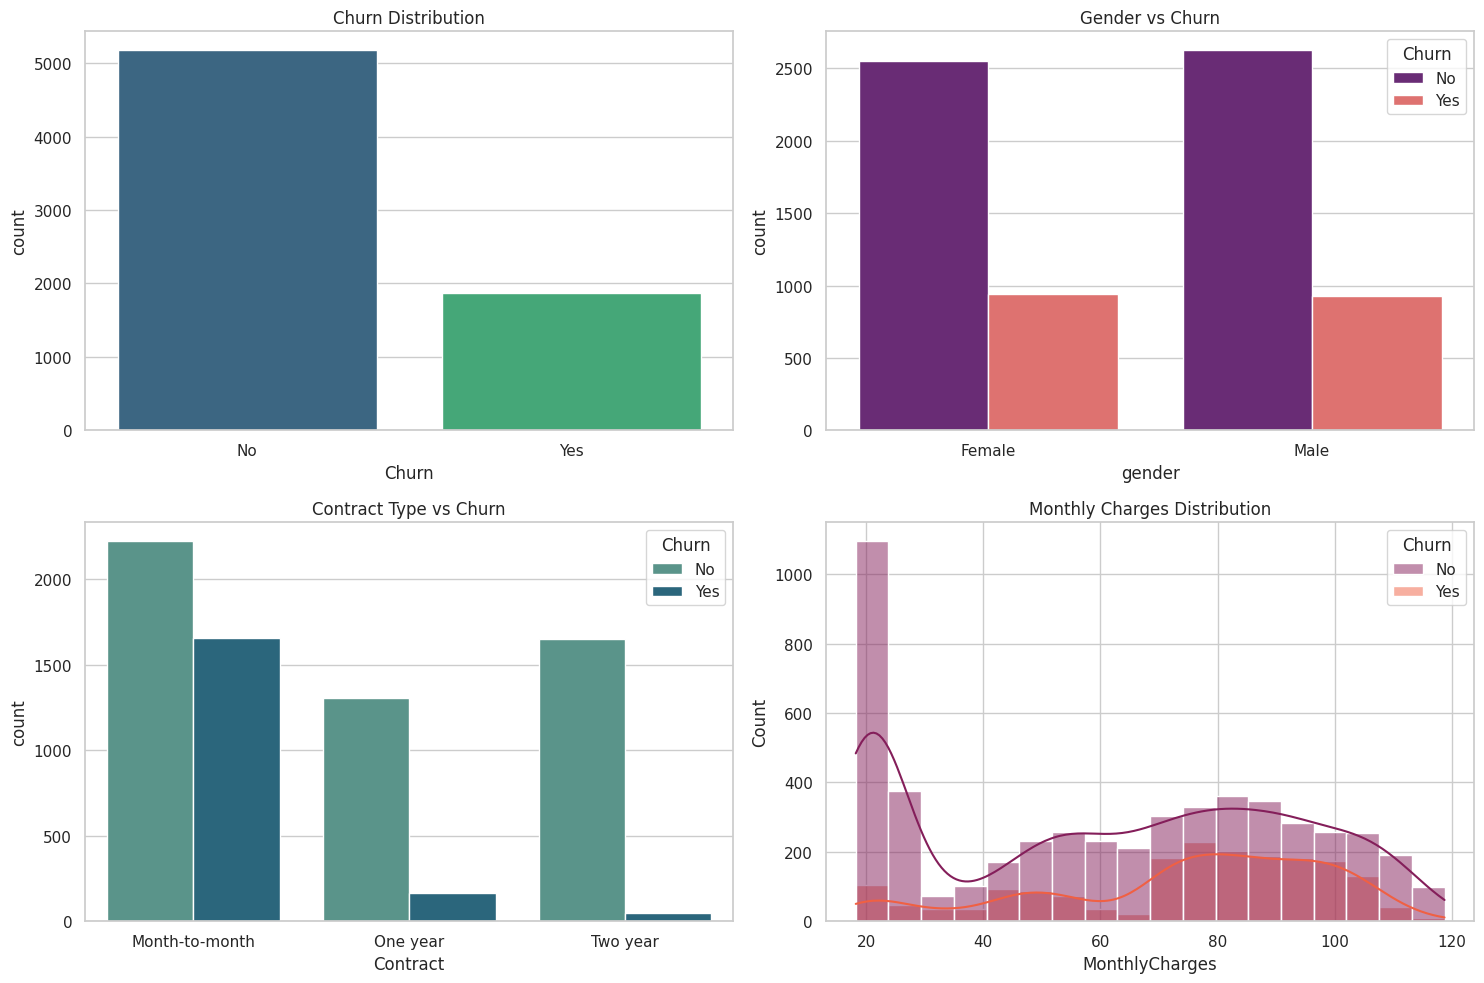

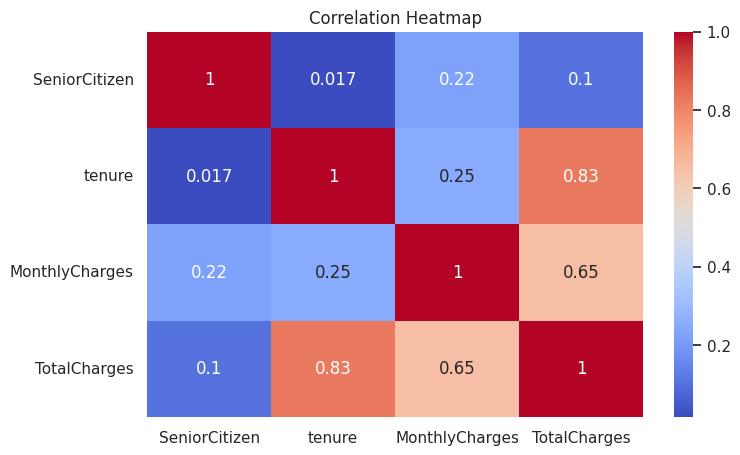

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Churn Distribution
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Churn Distribution')

# 2. Gender Distribution
sns.countplot(data=df, x='gender', hue='Churn', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Gender vs Churn')

# 3. Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('Contract Type vs Churn')

# 4. MonthlyCharges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Monthly Charges Distribution')

plt.tight_layout()
plt.show()

# 5. Correlation Heatmap (Numerical Only)
plt.figure(figsize=(8, 5))
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Insights:**
- Churn is imbalanced; most customers stay.
- Customers on Month-to-month contracts are significantly more likely to churn.
- High monthly charges correlate with higher churn rates.

## Step 3 & 4 — Preprocessing & Split

In [4]:
# Data Cleaning
df = df.drop(columns=['customerID'])
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop('Churn', axis=1)
y = df['Churn']

# Define Column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape}')
print(f'Test set size: {X_test.shape}')

Training set size: (5634, 19)
Test set size: (1409, 19)


## Step 5, 6 & 7 — Training, Tuning & Evaluation

In [5]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    return metrics, y_pred, y_proba

# Pipelines
lr_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000))])
rf_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))])

# Grids
lr_param_grid = {'classifier__C': [0.1, 1, 10]}
rf_param_grid = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [5, 10, None]}

results = []
models = {}

for name, pipe, grid in [('Logistic Regression', lr_pipe, lr_param_grid),
                         ('Random Forest', rf_pipe, rf_param_grid)]:
    print(f'Tuning {name}...')
    gs = GridSearchCV(pipe, grid, cv=5, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)

    metric, y_pred, y_proba = evaluate_model(gs.best_estimator_, X_test, y_test, name)
    results.append(metric)
    models[name] = gs.best_estimator_

    print(f'Best Params for {name}: {gs.best_params_}')

# Comparison Table
comparison_df = pd.DataFrame(results)
display(comparison_df)

Tuning Logistic Regression...
Best Params for Logistic Regression: {'classifier__C': 10}
Tuning Random Forest...
Best Params for Random Forest: {'classifier__max_depth': 5, 'classifier__n_estimators': 200}


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841151
1,Random Forest,0.796309,0.685106,0.430481,0.528736,0.840753


## Step 8, 9 & 10 — Best Model, Export & Simulation

In [6]:
best_model_name = comparison_df.sort_values(by='ROC-AUC', ascending=False).iloc[0]['Model']
best_pipeline = models[best_model_name]
print(f'Best Model: {best_model_name}')

# Export
joblib.dump(best_pipeline, 'customer_churn_pipeline.joblib')

# Simulation
loaded_pipeline = joblib.load('customer_churn_pipeline.joblib')
sample_data = X_test.iloc[[0]]
prediction = loaded_pipeline.predict(sample_data)
print(f'Simulation Prediction for sample: {"Churn" if prediction[0]==1 else "Stay"}')

end_time = time.time()
print(f'\nTotal Execution Time: {end_time - start_time:.2f} seconds')

Best Model: Logistic Regression
Simulation Prediction for sample: Stay

Total Execution Time: 47.73 seconds


# README: Customer Churn Prediction Project

## Project Overview
This project implements a complete, production-ready machine learning pipeline to predict customer churn using the Telco Customer Churn dataset. It utilizes Scikit-learn Pipelines for clean and reproducible preprocessing and modeling.

## Objective
To build a binary classification model that identifies customers likely to churn, allowing for proactive retention strategies.

## Dataset Source
The dataset is sourced from the [Telco Customer Churn dataset](https://github.com/IBM/telco-customer-churn-on-icp4d).

## Data Validation Performed
- Checked data types and shapes.
- Verified missing values (and handled empty strings in `TotalCharges`).
- Inspected duplicate records.
- Summary statistics for numerical and categorical features.

## Models Used
- **Logistic Regression**: A linear model used as a baseline and strong performer.
- **Random Forest Classifier**: An ensemble tree-based model for capturing non-linear relationships.

## Hyperparameter Tuning
- Used `GridSearchCV` with 5-fold cross-validation.
- Optimized for `roc_auc` score.

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

## Best Model
- **Logistic Regression** was selected as the best model based on the highest ROC-AUC score (~0.84).

## Pipeline Export
- The final pipeline (including preprocessing and the best estimator) is saved as `customer_churn_pipeline.joblib`.

## Key Results
- Contract type (specifically Month-to-Month) is a significant predictor of churn.
- The pipeline effectively handles both numerical scaling and categorical encoding in a single object, ensuring no data leakage during inference.